In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('final_data.csv')

In [ ]:
def apply_local_timezone(df):
    """
    TRANSACTION_STATE를 기반으로 UTC 시간을 각 지역의 정확한 현지 시간으로 변환하는 함수
    """
    print("시간대 변환을 시작합니다. (데이터 크기에 따라 수초~수십초 소요될 수 있습니다)")
    
    # 1. State별 주요 Timezone 매핑 딕셔너리
    tz_mapping = {
        # Eastern Time (EST/EDT)
        'OH':'America/New_York', 'MI':'America/New_York', 'IN':'America/New_York', 'NC':'America/New_York', 
        'FL':'America/New_York', 'VA':'America/New_York', 'MA':'America/New_York', 'SC':'America/New_York', 
        'GA':'America/New_York', 'PA':'America/New_York', 'DE':'America/New_York', 'MD':'America/New_York', 
        'NY':'America/New_York', 'CT':'America/New_York', 'WV':'America/New_York', 'RI':'America/New_York', 
        'NJ':'America/New_York', 'DC':'America/New_York', 'ME':'America/New_York', 'VT':'America/New_York', 
        'NH':'America/New_York',
        
        # Central Time (CST/CDT)
        'MN':'America/Chicago', 'WI':'America/Chicago', 'TX':'America/Chicago', 'LA':'America/Chicago', 
        'IL':'America/Chicago', 'MS':'America/Chicago', 'TN':'America/Chicago', 'NE':'America/Chicago', 
        'MO':'America/Chicago', 'AL':'America/Chicago', 'ND':'America/Chicago', 'OK':'America/Chicago', 
        'IA':'America/Chicago', 'SD':'America/Chicago', 'AR':'America/Chicago', 'KS':'America/Chicago',
        
        # Mountain Time (MST/MDT)
        'CO':'America/Denver', 'UT':'America/Denver', 'NM':'America/Denver', 'ID':'America/Denver', 
        'MT':'America/Denver', 'WY':'America/Denver', 
        'AZ':'America/Phoenix', # 애리조나는 서머타임을 적용하지 않아 별도 분리
        
        # Pacific Time (PST/PDT)
        'CA':'America/Los_Angeles', 'NV':'America/Los_Angeles', 'WA':'America/Los_Angeles', 'OR':'America/Los_Angeles',
        
        # 기타 지역 및 해외 영토
        'AK':'America/Anchorage', 'HI':'Pacific/Honolulu', 
        'PR':'America/Puerto_Rico', 'VI':'America/Puerto_Rico', 'GU':'Pacific/Guam', 'MP':'Pacific/Guam', 'AS':'Pacific/Pago_Pago',
        
        # 군사 우편번호(AE, AP, AA) 등은 임의로 UTC나 동부시간으로 설정
        'AE':'UTC', 'AP':'UTC', 'AA':'America/New_York'
    }

    # 2. TRANSACTION_DATE를 Datetime 객체로 변환하고 기본값을 UTC로 명시
    if not pd.api.types.is_datetime64_any_dtype(df['TRANSACTION_DATE']):
        df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])
    
    if df['TRANSACTION_DATE'].dt.tz is None:
        df['TRANSACTION_DATE'] = df['TRANSACTION_DATE'].dt.tz_localize('UTC')

    # 3. 주(State)에 맞는 타임존 열 생성 (결측치는 우선 UTC로 처리)
    df['TZ_NAME'] = df['TRANSACTION_STATE'].map(tz_mapping).fillna('UTC')

    # 4. 각 타임존별로 변환 결과를 담을 빈 시리즈 생성
    local_times = pd.Series(index=df.index, dtype='datetime64[ns]')

    # 5. 각 고유 타임존별로 현지 시간 변환 (서머타임 자동 계산됨)
    for tz in df['TZ_NAME'].unique():
        mask = df['TZ_NAME'] == tz
        # 해당 지역의 시간으로 변환 후, 다시 tz-naive 형태로 껍데기를 벗겨야 한 컬럼에 합칠 수 있음
        local_times[mask] = df.loc[mask, 'TRANSACTION_DATE'].dt.tz_convert(tz).dt.tz_localize(None)

    # 6. 최종 컬럼 적용 및 요일/시간 추출
    df['LOCAL_TIME'] = local_times
    df['Hour'] = df['LOCAL_TIME'].dt.hour
    df['DayOfWeek'] = df['LOCAL_TIME'].dt.day_name()
    
    # 요일 순서 정렬
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=days_order, ordered=True)

    print("✅ 현지 시간(Local Time) 변환이 완료되었습니다!")
    return df

# 함수 실행하여 df 업데이트
df = apply_local_timezone(df)

시간대 변환을 시작합니다. (데이터 크기에 따라 수초~수십초 소요될 수 있습니다)
✅ 현지 시간(Local Time) 변환이 완료되었습니다!


In [4]:
df

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,...,CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION,TZ_NAME,LOCAL_TIME,Hour,DayOfWeek
0,A6184793,C7717436,T8535582,0.99,2024-03-13 06:46:55+00:00,Spend,OH,EUCLID,OH,WESTLAKE,...,26.25,29,Card Not Present,112,WENDYS,0,America/New_York,2024-03-13 02:46:55,2,Wednesday
1,A2296562,C5518346,T2383075,22.76,2024-05-16 20:34:18+00:00,Spend,MI,FORT GRATIOT,MI,FORT GRATIOT,...,NaN,87,Card Present,214,JIMMY JOHNS GOURMET SANDWICHES,2,America/New_York,2024-05-16 16:34:18,16,Thursday
2,A5523719,C7179772,T7494465,8.84,2024-04-25 17:09:37+00:00,Spend,OH,TOLEDO,OH,TOLEDO,...,100.33,25,Card Present,58,SUBWAY,0,America/New_York,2024-04-25 13:09:37,13,Thursday
3,A7905524,C1779514,T5897261,8.78,2024-05-26 13:50:06+00:00,Spend,IN,LAFAYETTE,IN,LAFAYETTE,...,NaN,26,Card Not Present,37,MCDONALDS,0,America/New_York,2024-05-26 09:50:06,9,Sunday
4,A7846687,C8240547,T2709494,18.01,2024-05-05 19:54:35+00:00,Spend,MN,DELANO,MN,DELANO,...,51.27,10,Card Present,522,CULVERS,0,America/Chicago,2024-05-05 14:54:35,14,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4771535,A5888006,C5879655,T9349512,8.99,2024-01-19 03:01:24+00:00,Spend,TX,KATY,TX,KATY,...,47.00,44,Card Present,250,PANDA EXPRESS,0,America/Chicago,2024-01-18 21:01:24,21,Thursday
4771536,A9047552,C5916637,T3621561,3.94,2024-06-08 14:20:56+00:00,Spend,OH,STEUBENVILLE,OH,STEUBENVILLE,...,65.58,17,Card Not Present,37,MCDONALDS,0,America/New_York,2024-06-08 10:20:56,10,Saturday
4771537,A8418819,C1462217,T3811323,2.07,2024-01-03 22:37:39+00:00,Spend,TN,HENDERSONVILLE,TN,HENDERSONVILLE,...,114.58,87,Card Present,1351,USCONNECT,2,America/Chicago,2024-01-03 16:37:39,16,Wednesday
4771538,A1621407,C1901728,T7678011,31.33,2024-04-25 17:53:37+00:00,Spend,IN,LYONS,NaN,NaN,...,62.58,83,Unknown,87,KFC,2,America/New_York,2024-04-25 13:53:37,13,Thursday


In [6]:
df.columns

Index(['ACCOUNT_ID', 'CARD_ID', 'TRANSACTION_ID', 'GROSS_TRANSACTION_AMOUNT',
       'TRANSACTION_DATE', 'TRANSACTION_TYPE', 'TRANSACTION_STATE',
       'TRANSACTION_CITY', 'MERCHANT_STATE', 'MERCHANT_CITY',
       'MERCHANT_CATEGORY_LEVEL_1', 'MERCHANT_CATEGORY_LEVEL_2',
       'MERCHANT_CATEGORY_LEVEL_3', 'TRANSACTION_DESCRIPTION', 'CARD_TYPE',
       'CARD_HOLDER_STATE', 'CARD_HOLDER_CITY', 'CARD_HOLDER_GENERATION',
       'CARD_HOLDER_TOTAL_TRANSACTION_COUNT', 'CARD_HOLDER_TOTAL_SPEND',
       'CARD_HOLDER_AVERAGE_LTM_SPEND',
       'CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT', 'CARD_HOLDER_VINTAGE',
       'CARD_PRESENT_INDICATOR', 'MERCHANT_ID', 'MERCHANT_NAME',
       'SHOPPER_CLASSIFICATION', 'TZ_NAME', 'LOCAL_TIME', 'Hour', 'DayOfWeek'],
      dtype='object')

C:\Users\yunji\AppData\Local\Temp\ipykernel_8596\218885045.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()


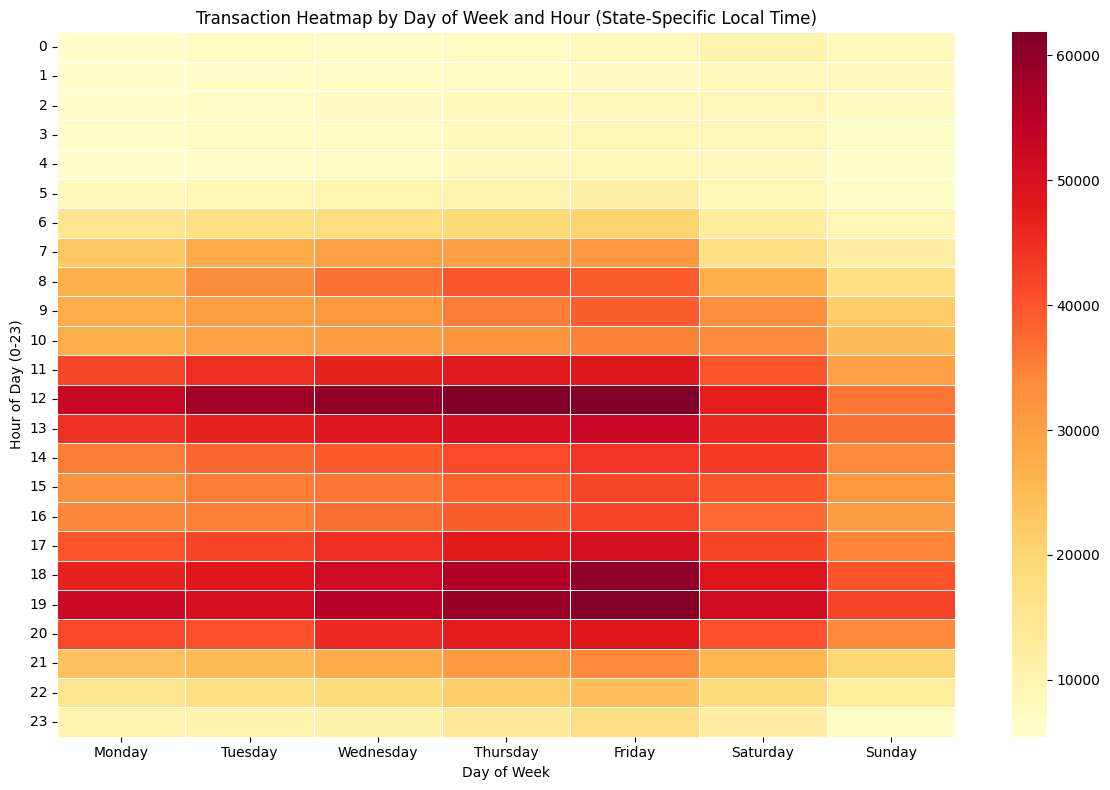

In [ ]:
# 5. 시간(행) x 요일(열) 기준 거래 건수 피벗 테이블 생성
heatmap_data = df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()

# 6. 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='.0f', linewidths=.5)

plt.title('Transaction Heatmap by Day of Week and Hour (State-Specific Local Time)')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day (0-23)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

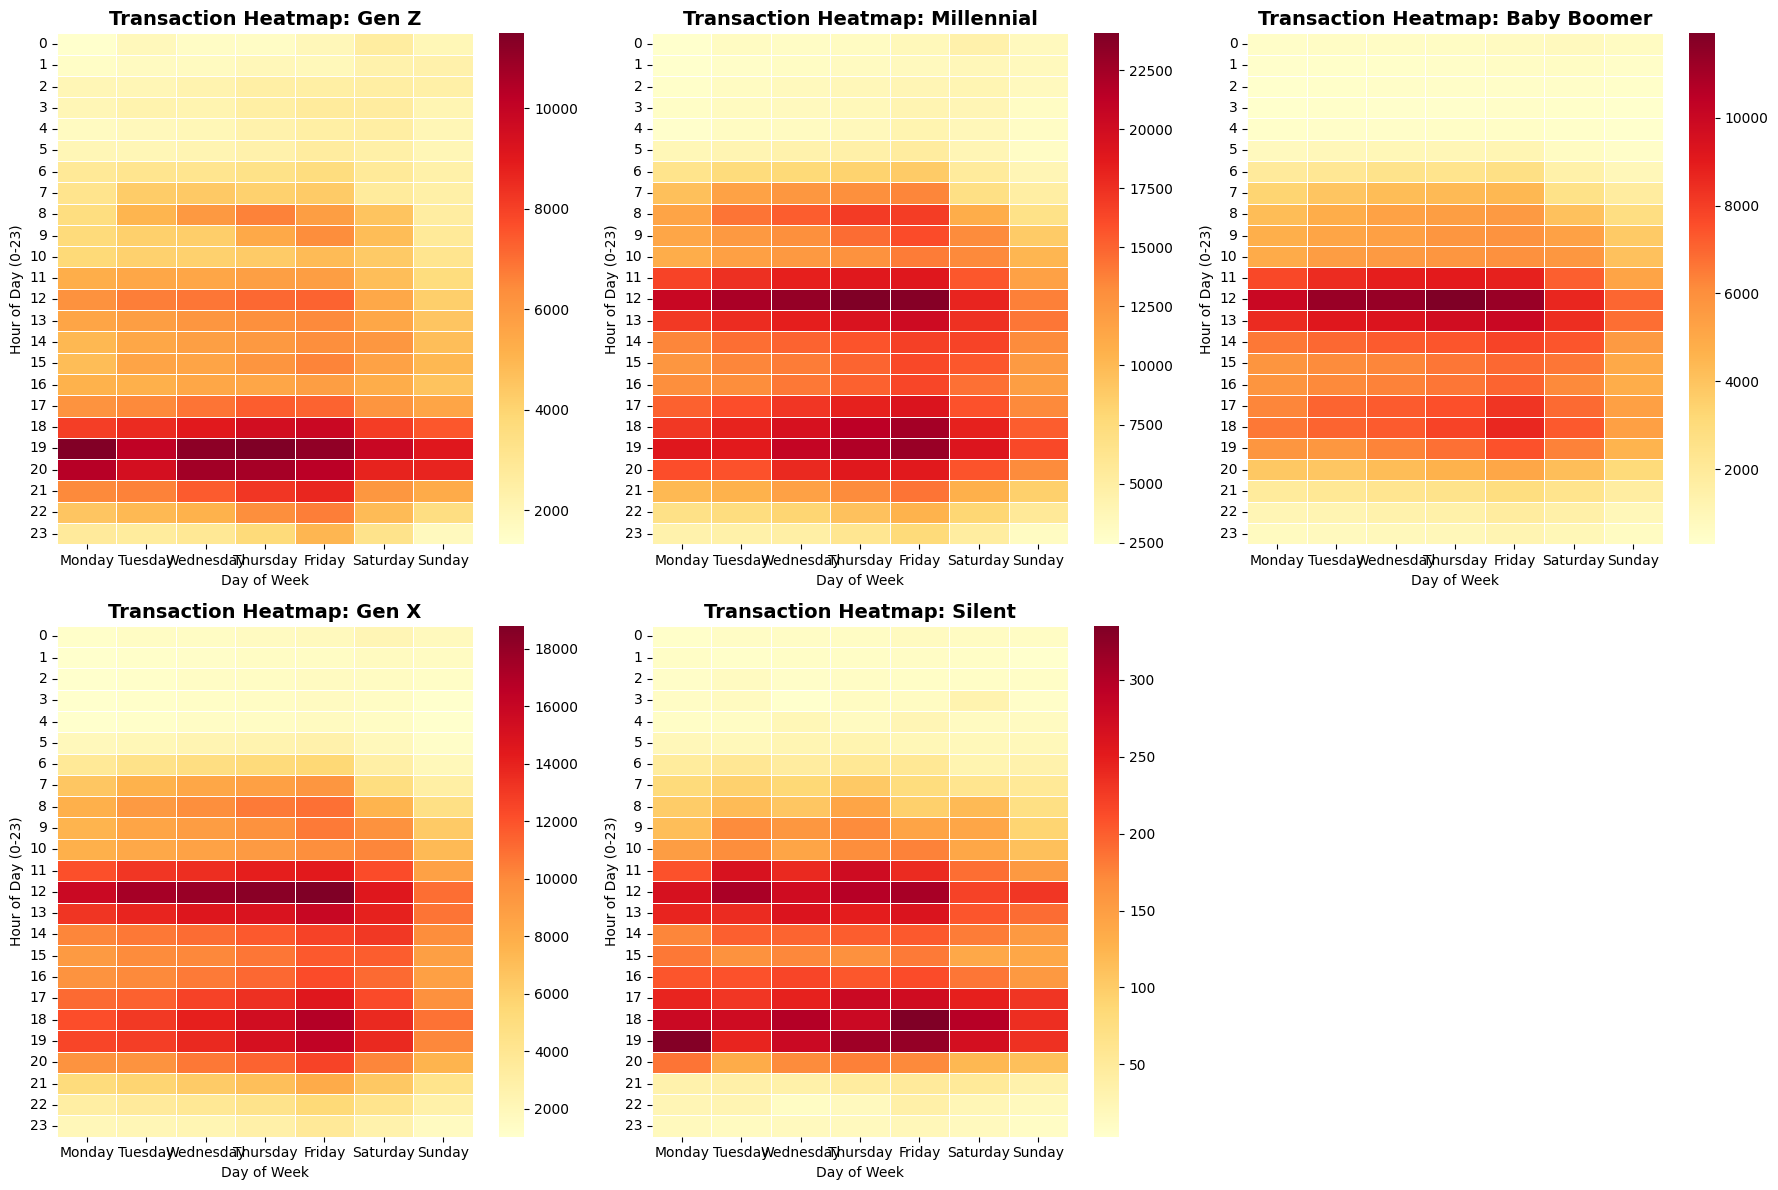

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 세대 목록 추출 (결측치 제외)
generations = df['CARD_HOLDER_GENERATION'].dropna().unique()

# 서브플롯(Grid) 크기 설정 (3열로 배치 기준)
cols = 3
# 3열일 경우 행의 개수를 구하는 정확한 공식: (데이터 개수 + 열 개수 - 1) // 열 개수
rows = (len(generations) + cols - 1) // cols 

# 전체 그래프 크기 동적 할당
fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))

# 세대 수가 1개라 axes가 1차원 배열이 아니거나, 
# 다차원 배열일 경우를 대비해 항상 1차원으로 안전하게 평탄화
if isinstance(axes, plt.Axes):
    axes = [axes]
else:
    axes = axes.flatten()

# 각 세대별로 히트맵 그리기
for i, gen in enumerate(generations):
    # 해당 세대 데이터만 필터링
    gen_df = df[df['CARD_HOLDER_GENERATION'] == gen]
    
    # 시간 x 요일 피벗 테이블 생성
    heatmap_data = gen_df.groupby(['Hour', 'DayOfWeek'], observed=False)['TRANSACTION_ID'].count().unstack()
    
    # 히트맵 시각화
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[i], annot=False, linewidths=.5)
    
    axes[i].set_title(f'Transaction Heatmap: {gen}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Day of Week')
    axes[i].set_ylabel('Hour of Day (0-23)')
    axes[i].tick_params(axis='x', rotation=0)

# 남는 빈 그래프 공간 숨기기 (예: 5개 세대인데 3x2=6칸을 만든 경우 마지막 1칸 지우기)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\yunji\AppData\Local\Temp\ipykernel_22508\4101288787.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_22508\4101288787.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_22508\4101288787.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to r

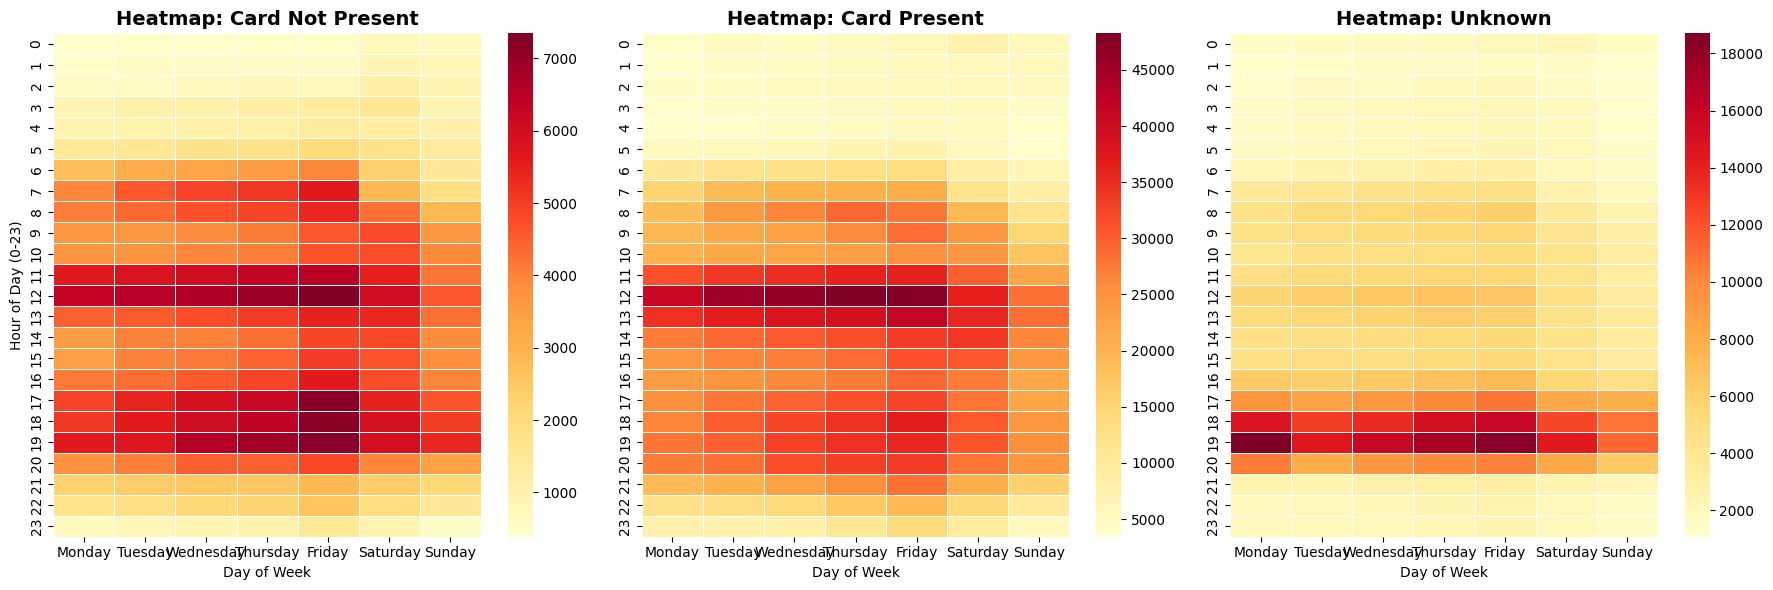

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CARD_PRESENT_INDICATOR의 고유값 추출 (결측치 제외)
indicators = df['CARD_PRESENT_INDICATOR'].dropna().unique()

# 1행 3열의 서브플롯 생성 (가로로 길게 배치)
fig, axes = plt.subplots(1, len(indicators), figsize=(18, 6))

for i, indicator in enumerate(indicators):
    # 해당 결제 방식 데이터만 필터링
    ind_df = df[df['CARD_PRESENT_INDICATOR'] == indicator]
    
    # 시간 x 요일 피벗 테이블 생성
    heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
    
    # 히트맵 시각화
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[i], annot=False, linewidths=.5)
    
    axes[i].set_title(f'Heatmap: {indicator}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Day of Week')
    
    # 첫 번째 그래프에만 y축 라벨(시간) 표시하여 깔끔하게 정리
    if i == 0:
        axes[i].set_ylabel('Hour of Day (0-23)')
    else:
        axes[i].set_ylabel('')
        
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [8]:
# 결제 방식(Present)과 카드 타입(Type) 교차표 생성
unknown_mystery_df = df.groupby(['CARD_PRESENT_INDICATOR', 'CARD_TYPE'])['TRANSACTION_ID'].count().unstack().fillna(0)

# 보기 편하게 정수형으로 변환
unknown_mystery_df = unknown_mystery_df.astype(int)
unknown_mystery_df

CARD_TYPE,Benefit - Health,Credit,Debit,General Purpose,Payroll
CARD_PRESENT_INDICATOR,,,,,
Card Not Present,2,169102,408824,315,0
Card Present,83,759409,2619385,2729,200
Unknown,0,63540,644691,40503,62757


In [16]:
# 1. 우리가 쫓는 타겟 데이터만 필터링 (Debit 이면서 Unknown 인 64만 건)
target_df = df[ (df['CARD_PRESENT_INDICATOR'] == 'Unknown')]

# 단서 1: '시간대'를 확인하자
print("🕒 [단서 1] 시간대별 결제 건수 (상위 5개 시간대)")
print(target_df['Hour'].value_counts())

# 단서 2: '어느 브랜드'에서 발생했는가? (특정 앱이나 가맹점의 문제일까?)
print("\n🏪 [단서 2] 가맹점(MERCHANT_NAME)별 결제 건수 TOP 10")
print(target_df['MERCHANT_NAME'].value_counts().head(10))

# 단서 3: '누가' 결제했는가? (Gen Z의 간편결제일까?)
print("\n🧑‍🤝‍🧑 [단서 3] 세대(GENERATION)별 결제 건수")
# 결측치(NaN)도 포함해서 출력 (익명 결제인지 확인하기 위함)
print(target_df['CARD_HOLDER_GENERATION'].value_counts(dropna=False))

🕒 [단서 1] 시간대별 결제 건수 (상위 5개 시간대)
Hour
19    110231
18     95595
17     64222
20     62860
16     43128
12     39666
13     37079
11     34596
14     33212
9      33193
15     33182
8      32976
10     31450
7      26490
21     18304
6      17001
22     14423
23     13893
5      13148
3      12240
4      12103
0      12065
2      11204
1       9230
Name: count, dtype: int64

🏪 [단서 2] 가맹점(MERCHANT_NAME)별 결제 건수 TOP 10
MERCHANT_NAME
NO ENTITY              203498
MCDONALDS              115812
STARBUCKS               64835
365 RETAIL MARKETS      50214
CHICK-FIL-A             31980
USA CANTEEN VENDING     24943
DUNKIN DONUTS           22847
TACO BELL               22770
DOMINOS                 18651
BURGER KING             15326
Name: count, dtype: int64

🧑‍🤝‍🧑 [단서 3] 세대(GENERATION)별 결제 건수
CARD_HOLDER_GENERATION
Millennial     318398
Gen X          202695
Gen Z          174284
Baby Boomer     78251
NaN             32595
Silent           5268
Name: count, dtype: int64


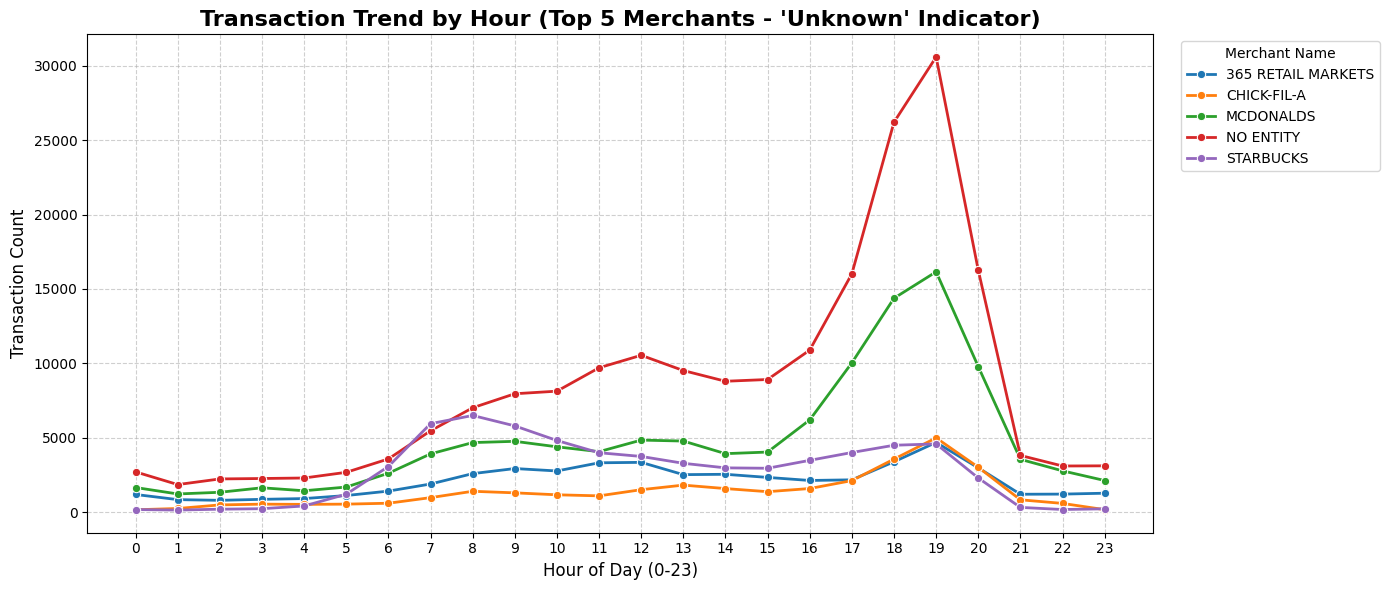

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Unknown 상태인 데이터 필터링 (이미 작성하신 부분)
target_df = df[df['CARD_PRESENT_INDICATOR'] == 'Unknown']

# 2. 전체 시간대 기준 상위 5개 MERCHANT_NAME 추출
top_5_merchants = target_df['MERCHANT_NAME'].value_counts().nlargest(5).index

# 3. 상위 5개 가맹점에 해당하는 데이터만 필터링
filtered_df = target_df[target_df['MERCHANT_NAME'].isin(top_5_merchants)]

# 4. 시간(Hour) x 가맹점(MERCHANT_NAME)별 결제 건수 집계 (Seaborn에 넣기 좋은 형태로 변환)
# size()로 건수를 세고, reset_index를 통해 데이터프레임 형태로 만듭니다.
trend_data = filtered_df.groupby(['Hour', 'MERCHANT_NAME']).size().reset_index(name='Transaction_Count')

# 5. 추이 그래프 (Line Plot) 시각화
plt.figure(figsize=(14, 6)) # 가로로 조금 더 넓게 설정 (범례 공간 확보)

# marker='o'를 넣으면 꺾이는 지점에 동그란 점이 찍혀서 각 시간대별 수치를 보기 편합니다.
sns.lineplot(
    data=trend_data, 
    x='Hour', 
    y='Transaction_Count', 
    hue='MERCHANT_NAME', 
    marker='o', 
    linewidth=2
)

# 6. 그래프 디테일 꾸미기
plt.title("Transaction Trend by Hour (Top 5 Merchants - 'Unknown' Indicator)", fontsize=16, fontweight='bold')
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Transaction Count", fontsize=12)

# x축 눈금을 0부터 23까지 빠짐없이 모두 표시
plt.xticks(range(0, 24))

# 그래프 선과 겹치지 않게 범례(Legend)를 그래프 바깥 우측 상단으로 이동
plt.legend(title='Merchant Name', bbox_to_anchor=(1.02, 1), loc='upper left')

# 눈금선(Grid) 추가하여 수치 읽기 쉽게 설정
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

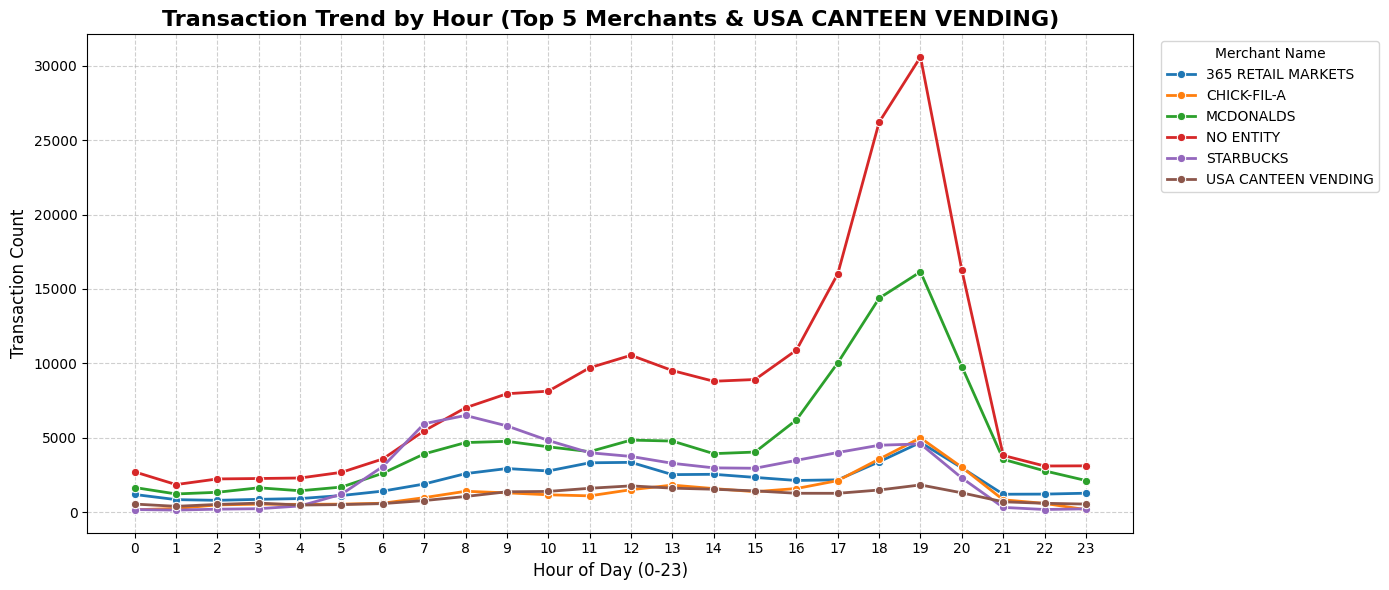

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Unknown 상태인 데이터 필터링
target_df = df[df['CARD_PRESENT_INDICATOR'] == 'Unknown']

# 2. 전체 시간대 기준 상위 5개 MERCHANT_NAME 추출 후 리스트로 변환
target_merchants = target_df['MERCHANT_NAME'].value_counts().nlargest(5).index.tolist()

# ★ 핵심 포인트: 특별히 보고 싶은 가맹점을 리스트에 강제 추가 ★
# (만약 이미 상위 5위 안에 있다면 중복 추가되지 않도록 조건문 처리)
special_merchant = 'USA CANTEEN VENDING'
if special_merchant not in target_merchants:
    target_merchants.append(special_merchant)

# 3. 타겟 가맹점(상위 5개 + USA CANTEEN VENDING)에 해당하는 데이터만 필터링
filtered_df = target_df[target_df['MERCHANT_NAME'].isin(target_merchants)]

# 4. 시간(Hour) x 가맹점(MERCHANT_NAME)별 결제 건수 집계
trend_data = filtered_df.groupby(['Hour', 'MERCHANT_NAME']).size().reset_index(name='Transaction_Count')

# 5. 추이 그래프 (Line Plot) 시각화
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=trend_data, 
    x='Hour', 
    y='Transaction_Count', 
    hue='MERCHANT_NAME', 
    marker='o', 
    linewidth=2
)

# 6. 그래프 디테일 꾸미기
plt.title("Transaction Trend by Hour (Top 5 Merchants & USA CANTEEN VENDING)", fontsize=16, fontweight='bold')
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Transaction Count", fontsize=12)

# x축 눈금을 0부터 23까지 빠짐없이 모두 표시
plt.xticks(range(0, 24))

# 범례(Legend)를 그래프 바깥 우측 상단으로 이동
plt.legend(title='Merchant Name', bbox_to_anchor=(1.02, 1), loc='upper left')

# 눈금선(Grid) 추가하여 수치 읽기 쉽게 설정
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [20]:
# 18시만 필터링
target_df[target_df['Hour'] == 16]['MERCHANT_NAME'].value_counts().head(10)

MERCHANT_NAME
NO ENTITY              10885
MCDONALDS               6192
STARBUCKS               3474
365 RETAIL MARKETS      2121
CHICK-FIL-A             1579
TACO BELL               1365
USA CANTEEN VENDING     1260
DOMINOS                 1174
WENDYS                   901
LITTLE CAESARS           883
Name: count, dtype: int64

In [57]:
df[df['TRANSACTION_DESCRIPTION'] == '000000000000000']

,ACCOUNT_ID,CARD_ID,TRANSACTION_ID,GROSS_TRANSACTION_AMOUNT,TRANSACTION_DATE,TRANSACTION_TYPE,TRANSACTION_STATE,TRANSACTION_CITY,MERCHANT_STATE,MERCHANT_CITY,...,CARD_HOLDER_AVERAGE_LTM_TRANSACTION_COUNT,CARD_HOLDER_VINTAGE,CARD_PRESENT_INDICATOR,MERCHANT_ID,MERCHANT_NAME,SHOPPER_CLASSIFICATION,TZ_NAME,LOCAL_TIME,Hour,DayOfWeek
2751,A9736162,C1587007,T4916257,9.83,2024-06-05 23:51:27+00:00,Spend,TN,FINLEY,NaN,NaN,...,108.25,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-06-05 18:51:27+00:00,18,Wednesday
4959,A1792049,C2486867,T6111116,8.46,2024-04-02 23:46:13+00:00,Spend,TN,JACKSON,NaN,NaN,...,62.33,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-04-02 18:46:13+00:00,18,Tuesday
6307,A4159296,C8359831,T5985095,1.43,2024-06-15 00:02:04+00:00,Spend,TN,DYERSBURG,NaN,NaN,...,69.08,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-06-14 19:02:04+00:00,19,Friday
6336,A9253076,C3783293,T2922103,1.37,2024-01-09 00:05:59+00:00,Spend,PA,YORK,NaN,NaN,...,91.00,4,Unknown,0,NO ENTITY,0,America/New_York,2024-01-08 19:05:59+00:00,19,Monday
8257,A5916341,C7358770,T1194161,4.38,2024-03-28 00:02:53+00:00,Spend,TN,FINLEY,NaN,NaN,...,130.42,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-03-27 19:02:53+00:00,19,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759508,A3512568,C4862673,T9214684,7.46,2024-01-30 00:06:22+00:00,Spend,TN,RIPLEY,NaN,NaN,...,158.42,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-01-29 19:06:22+00:00,19,Monday
4759649,A9795199,C1330707,T7694879,5.25,2024-02-02 23:54:57+00:00,Spend,TN,NEWBERN,NaN,NaN,...,85.08,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-02-02 18:54:57+00:00,18,Friday
4760889,A6414004,C5429951,T6849460,15.47,2024-06-07 23:50:50+00:00,Spend,TN,UNION CITY,NaN,NaN,...,17.75,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-06-07 18:50:50+00:00,18,Friday
4764399,A2789196,C2235476,T8885650,3.04,2024-05-11 00:08:39+00:00,Spend,TN,UNION CITY,NaN,NaN,...,52.50,61,Unknown,0,NO ENTITY,0,America/Chicago,2024-05-10 19:08:39+00:00,19,Friday


In [56]:
target_df[
    (target_df['Hour'] == 18) & 
    (target_df['MERCHANT_NAME'] == 'NO ENTITY')
]['TRANSACTION_DESCRIPTION'].value_counts().head(20)

TRANSACTION_DESCRIPTION
000000000000000                1357
JACKSONVILLE NC                 782
TAMPA         FL                598
SQUARE PURCHASE                 371
PEPSI BOTTLING VENTUR           326
365 Market  888 432-329         287
Store                           286
PREMIER FOOD SER                247
""""""JACKSONVILLE NC""""""     226
CSC Servicework                 203
CSC SERVICEWORK                 185
DAIRY QUEE DAIRY QUEE           153
844026101882                    152
VEND 1800-766-8728              149
SWANSBORO NC                    128
WILMINGTON NC                   123
RICHLANDS NC                    122
CONTINENTAL SERVICE             109
ALISON VENDING                  108
Continental Service             102
Name: count, dtype: int64

In [39]:
# Unknown 거래의 업종 분포
df[df['CARD_PRESENT_INDICATOR'] == 'Unknown'] \
  .groupby(['MERCHANT_CATEGORY_LEVEL_3']) \
  .size().sort_values(ascending=False).head(40)

MERCHANT_CATEGORY_LEVEL_3
QSR Burgers                      188072
Vending & Beverage Retailers     166779
Coffee / Tea                      84430
QSR Chicken                       62096
Mexican Restaurants               44364
Pizza Restaurants                 40117
QSR Sandwiches                    37089
Breakfast Restaurants             25582
Dessert                           20126
American Restaurants              19857
Payment Services                  16587
Food Services                     13536
General Retail                    10943
Asian Restaurants                  7489
Grocery                            4968
QSR Smoothies                      4948
Military Retailers                 3555
Food Delivery                      2888
Business Services                  1306
Seafood Restaurants                1047
Amusement Parks                    1041
QSR Healthy                         873
Gas / Convenience                   324
Home Furnishing Retailers           324
Nutrition & Vi

In [28]:
df[df['CARD_PRESENT_INDICATOR'] == 'Unknown']['MERCHANT_NAME'].value_counts().head(30)

MERCHANT_NAME
NO ENTITY                              203498
MCDONALDS                              115812
STARBUCKS                               64835
365 RETAIL MARKETS                      50214
CHICK-FIL-A                             31980
USA CANTEEN VENDING                     24943
DUNKIN DONUTS                           22847
TACO BELL                               22770
DOMINOS                                 18651
BURGER KING                             15326
WENDYS                                  14432
SONIC DRIVE-IN                          12731
CHIPOTLE                                12626
SUBWAY                                  11563
AVANTI MARKETS                          10793
LITTLE CAESARS                          10400
NAYAX                                    8581
USCONNECT                                7722
CRANE MERCHANDISING SYSTEMS              7563
WHATABURGER                              6434
PANERA BREAD                             6187
PAPA JOHNS          

In [18]:
unknown = df[df['CARD_PRESENT_INDICATOR'] == 'Unknown']

# 같은 시간에 동일 가맹점에서 얼마나 묶여서 나오나?
unknown.groupby(['MERCHANT_ID', 'TRANSACTION_DATE']).size().sort_values(ascending=False).head(20)

MERCHANT_ID  TRANSACTION_DATE         
0            2024-05-16 00:06:38+00:00    5
             2024-06-18 00:06:24+00:00    5
             2024-04-25 00:04:10+00:00    4
             2024-04-06 00:09:54+00:00    4
             2024-03-05 00:06:59+00:00    4
             2024-02-08 23:51:58+00:00    4
             2024-04-04 23:50:27+00:00    4
             2024-01-27 00:14:15+00:00    4
             2024-01-30 00:03:10+00:00    4
             2024-01-29 23:45:34+00:00    4
             2024-01-15 23:51:57+00:00    4
             2024-04-19 23:52:16+00:00    4
             2024-02-27 00:00:44+00:00    4
             2024-06-23 00:05:09+00:00    4
             2024-06-04 00:03:25+00:00    4
             2024-06-15 23:58:48+00:00    4
             2024-03-23 00:05:51+00:00    4
             2024-04-19 00:12:55+00:00    4
             2024-04-05 00:04:36+00:00    4
             2024-06-29 00:03:19+00:00    4
dtype: int64

In [20]:
df[df['CARD_PRESENT_INDICATOR'] == 'Unknown'].groupby(['CARD_TYPE', 'CARD_HOLDER_GENERATION']).size().unstack()

CARD_HOLDER_GENERATION,Baby Boomer,Gen X,Gen Z,Millennial,Silent
CARD_TYPE,,,,,
Credit,12867,15928,5113,29063,537
Debit,58389,161138,144700,249534,4414
General Purpose,3230,11255,6895,15892,172
Payroll,3765,14374,17576,23909,145


In [42]:
# 이걸 확인해야 퍼즐이 진짜 완성됨
df.groupby('CARD_HOLDER_GENERATION')['CARD_PRESENT_INDICATOR'] \
  .value_counts(normalize=True).unstack()

CARD_PRESENT_INDICATOR,Card Not Present,Card Present,Unknown
CARD_HOLDER_GENERATION,,,
Baby Boomer,0.079575,0.807457,0.112968
Gen X,0.103874,0.738241,0.157885
Gen Z,0.130908,0.657239,0.211852
Millennial,0.136856,0.695237,0.167907
Silent,0.061641,0.682470,0.255890


In [25]:
for hour in [12, 13, 18, 19]:
    print(f"\n🕒 {hour}시 NO ENTITY  TOP 5")
    print(
        target_df[
            (target_df['Hour'] == hour) & 
            (target_df['MERCHANT_NAME'] == 'NO ENTITY')
        ]['MERCHANT_CATEGORY_LEVEL_3'].value_counts().head(5)
    )


🕒 12시 NO ENTITY  TOP 5
MERCHANT_CATEGORY_LEVEL_3
Vending & Beverage Retailers    5016
Dessert                         1058
Coffee / Tea                     694
General Retail                   559
Food Services                    511
Name: count, dtype: int64

🕒 13시 NO ENTITY  TOP 5
MERCHANT_CATEGORY_LEVEL_3
Vending & Beverage Retailers    4325
Dessert                         1091
Coffee / Tea                     635
General Retail                   498
Food Services                    496
Name: count, dtype: int64

🕒 18시 NO ENTITY  TOP 5
MERCHANT_CATEGORY_LEVEL_3
Vending & Beverage Retailers    4923
Dessert                         1591
Food Services                   1479
General Retail                  1428
Coffee / Tea                    1397
Name: count, dtype: int64

🕒 19시 NO ENTITY  TOP 5
MERCHANT_CATEGORY_LEVEL_3
Vending & Beverage Retailers    5610
Dessert                         1841
Military Retailers              1657
Food Services                   1604
General Retail     

In [26]:
for hour in [12, 13, 18, 19]:
    print(f"\n🕒 {hour}시 TOP 5")
    print(
        target_df[
            (target_df['Hour'] == hour)
        ]['CARD_TYPE'].value_counts().head(5)
    )


🕒 12시 TOP 5
CARD_TYPE
Debit              32603
Credit              5915
Payroll              800
General Purpose      348
Name: count, dtype: int64

🕒 13시 TOP 5
CARD_TYPE
Debit              30585
Credit              5000
Payroll             1038
General Purpose      456
Name: count, dtype: int64

🕒 18시 TOP 5
CARD_TYPE
Debit              78208
Payroll             9877
General Purpose     3882
Credit              3628
Name: count, dtype: int64

🕒 19시 TOP 5
CARD_TYPE
Debit              90243
Payroll            10993
Credit              4663
General Purpose     4332
Name: count, dtype: int64


In [ ]:
for hour in [12, 13, 18, 19]:
    print(f"\n🕒 {hour}시 NO ENTITY TRANSACTION_DESCRIPTION TOP 10")
    print(
        df[
            (df['Hour'] == hour) & 
            (df['MERCHANT_NAME'] == 'NO ENTITY')
        ]['CARD_TYPE'].value_counts().head(5)
    )

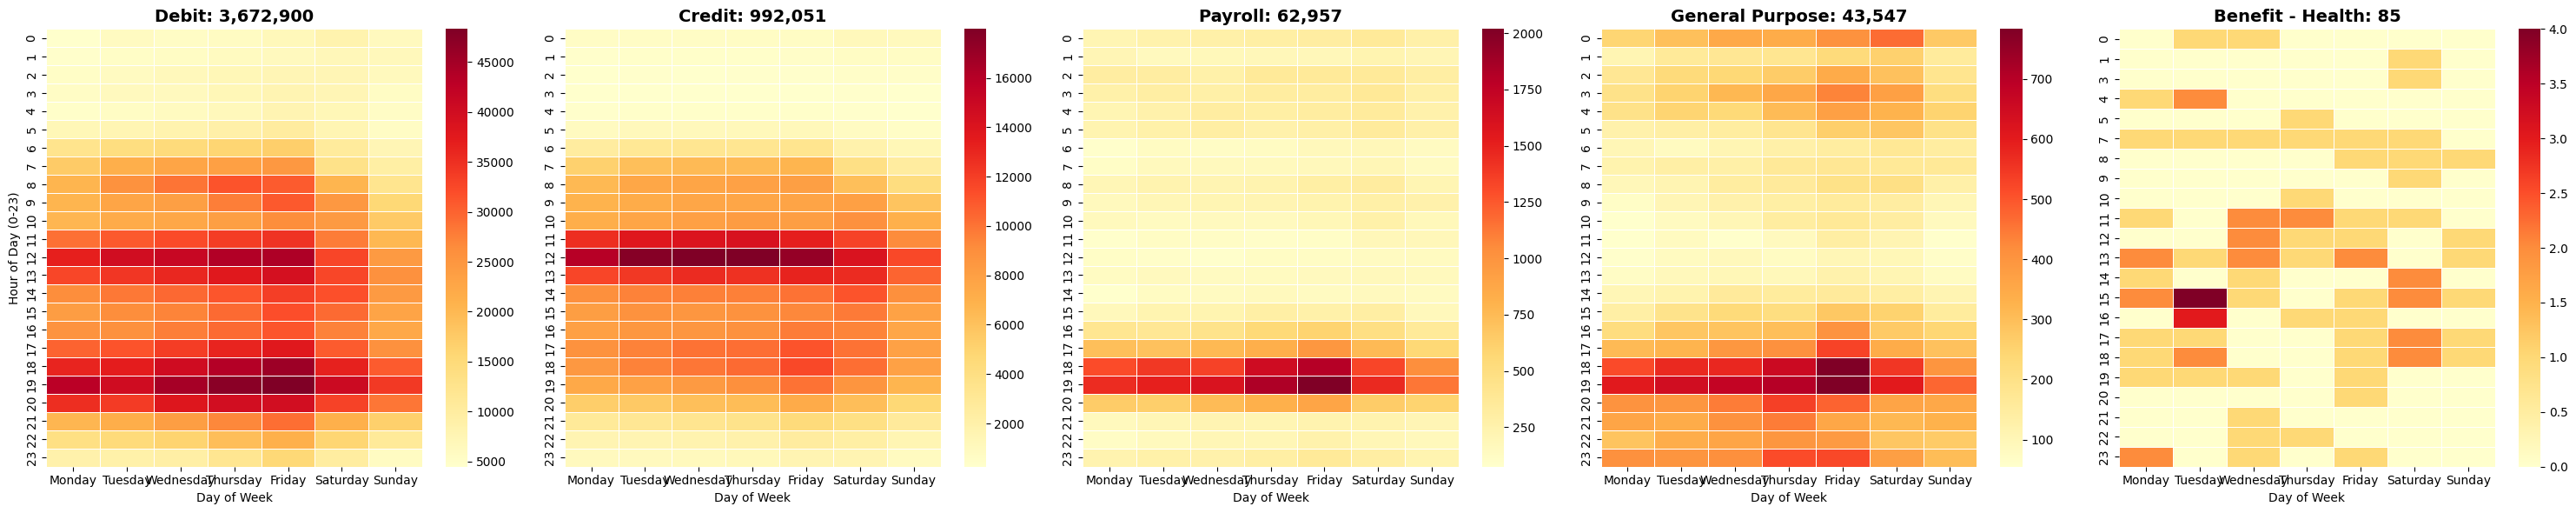

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

indicators = df['CARD_TYPE'].dropna().unique()

# 카드 타입 개수에 맞춰 가로 길이(figsize)를 동적으로 조절 
fig, axes = plt.subplots(1, len(indicators), figsize=(6 * len(indicators), 6))

# indicators가 하나일 경우 axes가 배열이 아닐 수 있으므로 리스트로 변환
if len(indicators) == 1:
    axes = [axes]

for i, indicator in enumerate(indicators):
    # 해당 카드 타입 데이터만 필터링
    ind_df = df[df['CARD_TYPE'] == indicator]
    
    # 해당 카드 타입의 총 거래 건수 계산
    transaction_count = ind_df.shape[0]
    
    # 시간 x 요일 피벗 테이블 생성 (Categorical 경고 방지 및 요일 순서 유지를 위해 observed=False 추가)
    heatmap_data = ind_df.groupby(['Hour', 'DayOfWeek'], observed=False)['TRANSACTION_ID'].count().unstack()
    
    # 히트맵 시각화
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[i], annot=False, linewidths=.5)
    
    # 제목: 카드 타입명과 거래 건수 표시 (천 단위 콤마 추가 - 훌륭한 디테일!)
    axes[i].set_title(f'{indicator}: {transaction_count:,}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Day of Week')
    
    # 첫 번째 그래프에만 y축 라벨 표시
    if i == 0:
        axes[i].set_ylabel('Hour of Day (0-23)')
    else:
        axes[i].set_ylabel('')
        
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\1960999885.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = filtered_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\1960999885.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = filtered_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
C:\Users\yunji\AppData\Local\Temp\ipykernel_18996\1960999885.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

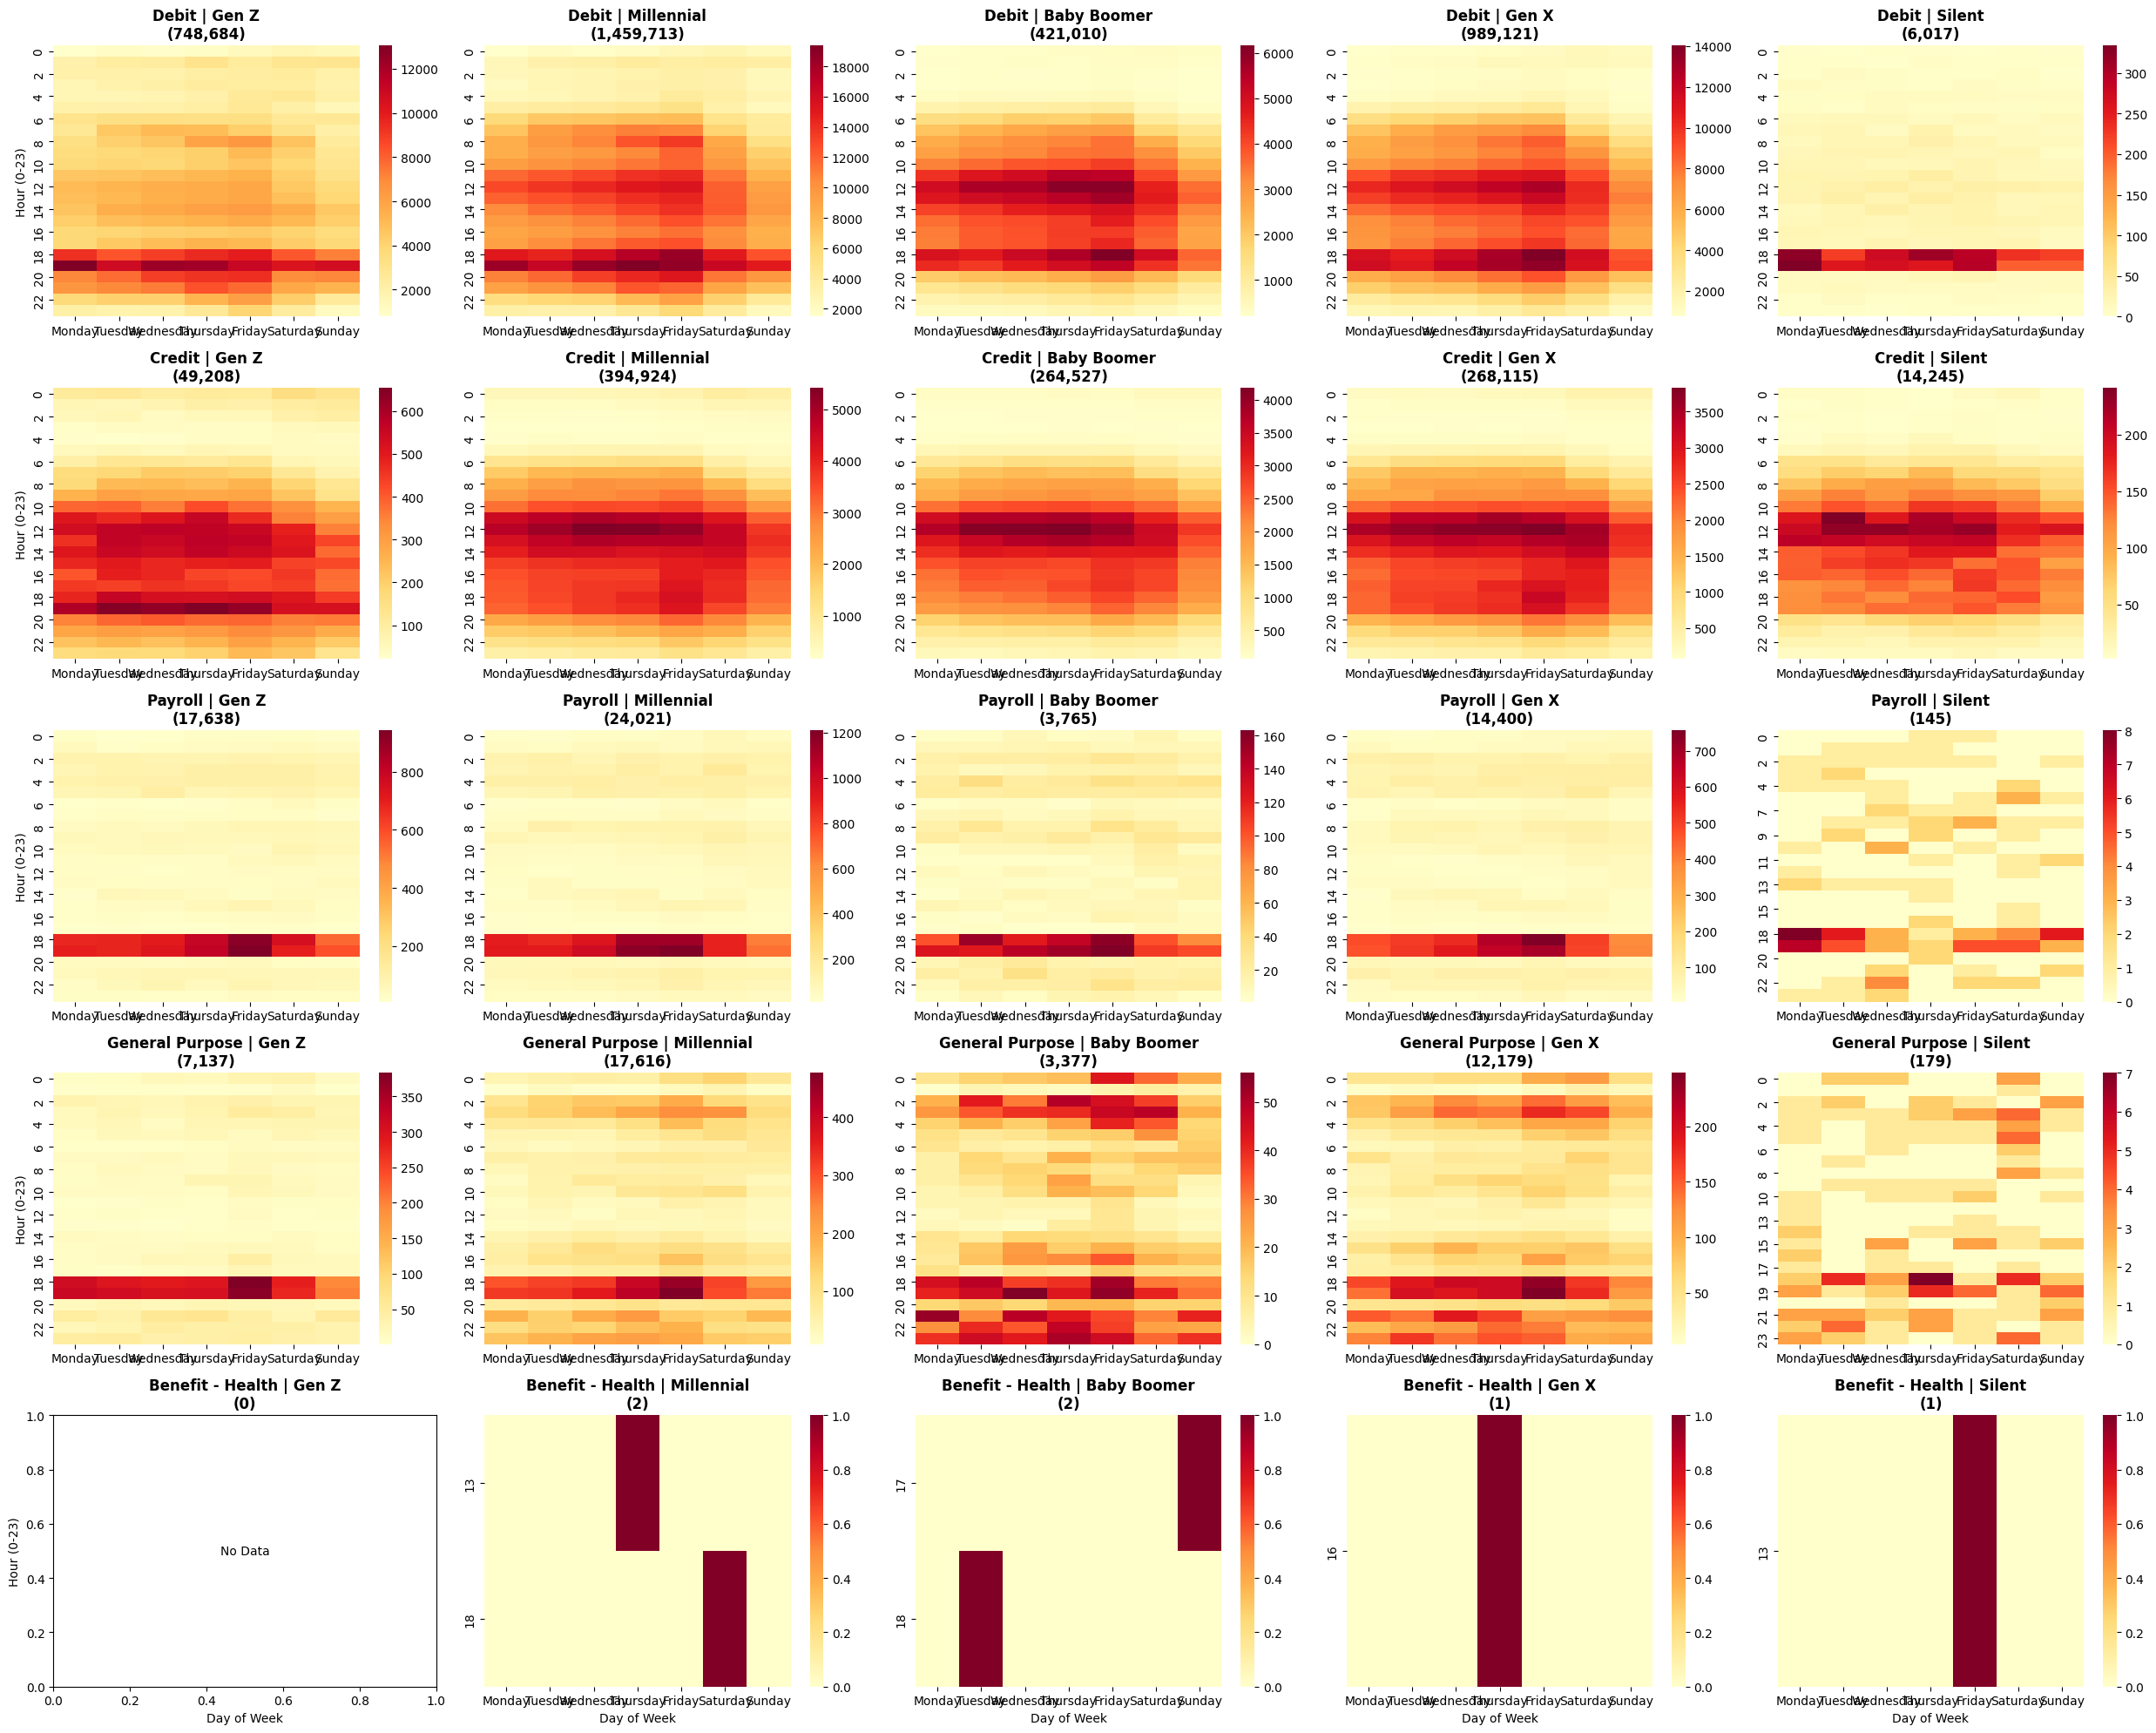

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# 고유값 추출 (결측치 제외)
card_types = df['CARD_TYPE'].dropna().unique()
generations = df['CARD_HOLDER_GENERATION'].dropna().unique()

# 5행 5열의 서브플롯 생성 (전체 크기를 넉넉하게 잡습니다)
fig, axes = plt.subplots(len(card_types), len(generations), figsize=(25, 20))

for i, card_type in enumerate(card_types):
    for j, gen in enumerate(generations):
        # 해당 카드 타입 + 해당 세대 데이터 필터링
        filtered_df = df[(df['CARD_TYPE'] == card_type) & 
                         (df['CARD_HOLDER_GENERATION'] == gen)]
        
        # 거래 건수 계산
        count = filtered_df.shape[0]
        
        # 데이터가 있는 경우에만 히트맵 생성 (빈 데이터프레임 오류 방지)
        if count > 0:
            # 시간 x 요일 피벗 테이블 생성
            heatmap_data = filtered_df.groupby(['Hour', 'DayOfWeek'])['TRANSACTION_ID'].count().unstack()
            
            # 히트맵 시각화 (컬러바는 너무 많으면 지저분하므로 cbar=False 옵션 고려 가능)
            sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[i, j], annot=False, cbar=True)
        else:
            # 데이터가 없는 칸은 빈 상태로 두고 안내 텍스트 표시
            axes[i, j].text(0.5, 0.5, 'No Data', ha='center', va='center')

        # 제목 설정: 카드 타입 - 세대: 건수
        axes[i, j].set_title(f'{card_type} | {gen}\n({count:,})', fontsize=12, fontweight='bold')
        
        # 레이아웃 정리를 위해 축 라벨 제어
        if i == len(card_types) - 1:
            axes[i, j].set_xlabel('Day of Week')
        else:
            axes[i, j].set_xlabel('')
            
        if j == 0:
            axes[i, j].set_ylabel('Hour (0-23)')
        else:
            axes[i, j].set_ylabel('')

        axes[i, j].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()